In [60]:
import os.path

import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns
from algbench import read_as_pandas
import matplotlib.ticker as ticker

import re
import json

font = {'family': 'serif', 'size': 11}
matplotlib.rc('font', **font)

matplotlib.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=[
    "#6E2C00",
    "#089099",
    "#27AE60",  # ip
    "#9B59B6",  # cp-sat
])

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['figure.figsize'] = [9, 3.5]

In [47]:
algorithm_mapping = {
    "ip": "GUROBI (with timeout)",
    "cp-sat": "CP-SAT (with timeout)",
    "combo": "COMBO (with timeout)",
    "qtg": "QTG",
}
hue_order = [
    algorithm_mapping["ip"],
    algorithm_mapping["cp-sat"],
    algorithm_mapping["qtg"]
]

In [65]:
paths = ['classical_qtg_comparison/small', 'classical_qtg_comparison/large']

qtg_results = pd.concat([read_as_pandas(f'results/quantum_benchmark/{path}', lambda row: {
    'algorithm': 'qtg',
    'algorithm_human_readable': algorithm_mapping["qtg"],
    'size': row['parameters']['args']['instance']['size'],
    'elapsed_cycles': np.average([measure['cycle_count'] for measure in row['result']['measurements']]),
    'instance': row['parameters']['args']['instance']['name'],
}) for path in paths], ignore_index=True)

ctg_results = pd.concat([read_as_pandas(f'results/ctg/{path}', lambda row: {
    'algorithm': 'ctg',
    'algorithm_human_readable': 'QTG',
    'elapsed_cycles': np.average(row['result']['elapsed_cycles']),
    'size': row['parameters']['args']['instance']['size'],
    'instance': row['parameters']['args']['instance']['name'],
    'qtg_estimate_cycles': np.average(
        [it * row['result']['qtg_cycles'] for it in row['result']['total_iterations']]),
    'objective_values': row['result']['objective_values'],
}) for path in paths if os.path.isdir(f'results/ctg/{path}/results')], ignore_index=True)

with open("cached/optimal_solutions.json", "r") as f:
    optimal_solutions = json.load(f)

classical_results = read_as_pandas(f'results/heuristics', lambda row: {
    'algorithm': row['parameters']['args']['solver'],
    'algorithm_human_readable': algorithm_mapping[row['parameters']['args']['solver']],
    'size': row['parameters']['args']["kwargs"]['instance']['size'],
    'instance': row['parameters']['args']["kwargs"]['instance']['name'],
    'objective_value': row['result']['objective_value'],
    'optimal': optimal_solutions[row['parameters']['args']["kwargs"]['instance']['name']]["objective"] == row['result'][
        'objective_value']
})


def parse_combo(row):
    if row['parameters']['args']['solver'] != "combo":
        return None

    ctg_solution = ctg_results[ctg_results["instance"] == row['parameters']['args']['instance']['name']]
    assert len(ctg_solution) == 1, ctg_solution
    qtg_estimate_cycles = ctg_solution.iloc[0]['qtg_estimate_cycles']

    return {
        'algorithm': row['parameters']['args']['solver'],
        'algorithm_human_readable': algorithm_mapping[row['parameters']['args']['solver']],
        'size': row['parameters']['args']['instance']['size'],
        'instance': row['parameters']['args']['instance']['name'],
        'objective_value': row['result']['objective_value'],
        'elapsed_cycles': row['result']['elapsed_cycles'],
        'optimal': row['result']['elapsed_cycles'] <= qtg_estimate_cycles
    }


combo_results = pd.concat([read_as_pandas(f'results/classical_benchmark/{path}', parse_combo) for path in paths],
                          ignore_index=True)

classical_results = pd.concat([classical_results, combo_results], ignore_index=True)

apply_g = lambda row: int(re.match(r'.+\_g\_([0-9]+)\_.+', row['instance']).group(1))

classical_results['g'] = classical_results.apply(apply_g, axis=1)

qtg_results['g'] = qtg_results.apply(apply_g, axis=1)
ctg_results['g'] = ctg_results.apply(apply_g, axis=1)


def g_group(row):
    if row['g'] == 2:
        return "$g=2$"
    elif row['g'] > 2 and row['g'] <= 6:
        return "$3 \\leq g \\leq 6$"
    return "$7 \\leq g \\leq 10$"


ctg_results['g_group'] = ctg_results.apply(g_group, axis=1)
qtg_results['g_group'] = qtg_results.apply(g_group, axis=1)
classical_results['g_group'] = classical_results.apply(g_group, axis=1)

In [66]:
ctg_results["optimal"] = ctg_results.apply(
    lambda row: sum(
        [1 for obj in row['objective_values'] if
         obj == combo_results[combo_results["instance"] == row['instance']].iloc[0]["objective_value"]]) / len(
        row['objective_values']), axis=1)

In [50]:
classical_results.groupby(['algorithm', "optimal"]).count()

algorithm_human_readable  size  elapsed_cycles  instance  \
algorithm optimal                                                             
combo     False                         199   199               0       199   
          True                          449   449               0       449   
cp-sat    False                         313   313             313       313   
          True                          335   335             335       335   
ip        False                         623   623             623       623   
          True                           25    25              25        25   

                   objective_value    g  g_group  
algorithm optimal                                 
combo     False                199  199      199  
          True                 449  449      449  
cp-sat    False                313  313      313  
          True                 335  335      335  
ip        False                623  623      623  
          True                  25   25       25

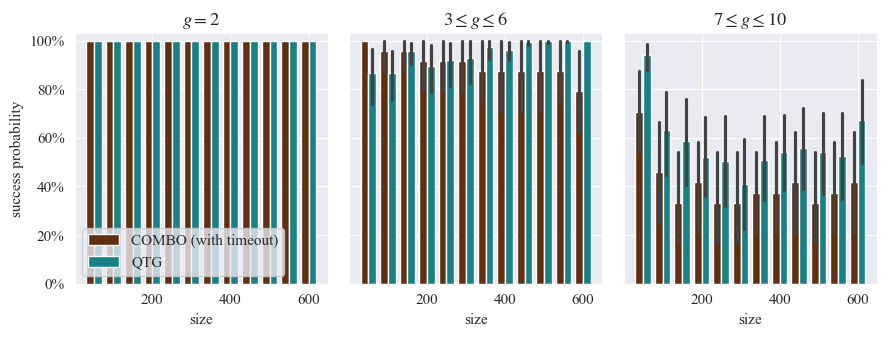

In [63]:

success_prob_comparison = pd.concat([
    classical_results[classical_results["algorithm"] == "combo"],
    ctg_results
], ignore_index=True)

fig, axs = plt.subplots(figsize=(9, 3.5), ncols=3)

for i, val in enumerate(['$g=2$', '$3 \\leq g \\leq 6$', '$7 \\leq g \\leq 10$']):
    ax = axs[i]
    current_comparison = success_prob_comparison[(success_prob_comparison['g_group'] == val)]

    sns.barplot(current_comparison,
                hue="algorithm_human_readable", dodge=True, x='size', y='optimal', ax=ax, native_scale=True)

    if i == 0:
        ax.set_ylabel("success probability")
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))
        ax.legend(loc="lower left").set_title(None)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
        ax.legend().remove()

    ax.set_ylim(0, 1.03)

    ax.set_title(val)

fig.tight_layout()
plt.savefig(f"out/12_combo_success_prob_with_qtg_runtime.pdf", bbox_inches='tight')

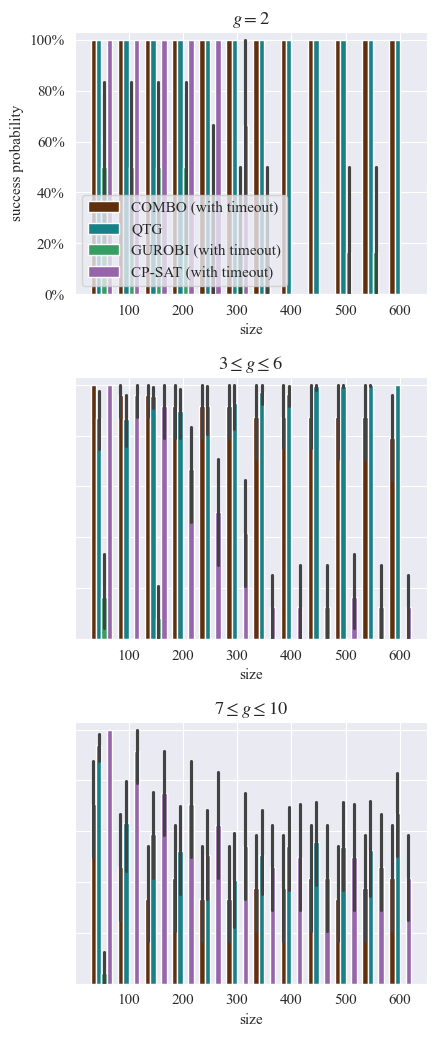

In [64]:
success_prob_comparison = pd.concat([
    classical_results,
    ctg_results
], ignore_index=True)

fig, axs = plt.subplots(figsize=(4.5, 10.5), nrows=3)

for i, val in enumerate(['$g=2$', '$3 \\leq g \\leq 6$', '$7 \\leq g \\leq 10$']):
    ax = axs[i]
    current_comparison = success_prob_comparison[(success_prob_comparison['g_group'] == val)]

    sns.barplot(current_comparison,
                hue="algorithm_human_readable", dodge=True, x='size', y='optimal', ax=ax, native_scale=True,
                hue_order=[
                    algorithm_mapping["combo"],
                    algorithm_mapping["qtg"],
                    algorithm_mapping["ip"],
                    algorithm_mapping["cp-sat"],
                ])

    if i == 0:
        ax.set_ylabel("success probability")
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))
        ax.legend(loc="lower left").set_title(None)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
        ax.legend().remove()

    ax.set_ylim(0, 1.03)

    ax.set_title(val)

fig.tight_layout()
plt.savefig(f"out/12_success_prob_with_qtg_runtime.pdf", bbox_inches='tight')

In [ ]:
success_prob_comparison = pd.concat([
    classical_results[classical_results["algorithm"] == "combo"],
    ctg_results
], ignore_index=True)

fig, axs = plt.subplots(figsize=(9, 3.5), ncols=3)

for i, val in enumerate(['$g=2$', '$3 \\leq g \\leq 6$', '$7 \\leq g \\leq 10$']):
    ax = axs[i]
    current_comparison = success_prob_comparison[(success_prob_comparison['g_group'] == val)]

    sns.barplot(current_comparison,
                hue="algorithm_human_readable", dodge=True, x='size', y='optimal', ax=ax, native_scale=True)

    if i == 0:
        ax.set_ylabel("success probability")
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))
        ax.legend(loc="lower left").set_title(None)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
        ax.legend().remove()

    ax.set_ylim(0, 1.03)

    ax.set_title(val)

fig.tight_layout()
plt.savefig(f"out/12_combo_success_prob_with_qtg_runtime.pdf", bbox_inches='tight')